In [1]:
import time
import xarray as xr
import numpy as np
import s3fs
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
import cartopy
import earthaccess
from earthaccess import Auth, DataCollections, DataGranules, Store
%matplotlib inline

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Code from https://podaac.github.io/tutorials/notebooks/datasets/DirectCloud_Access_SWOT_Oceanography.html

In [2]:
auth = earthaccess.login()

In [3]:
def init_cartopy(projection, box, latstep, lonstep, land, zorder=4,**karg):
    import cartopy
    import matplotlib.ticker as mticker
    import cartopy.feature as cfeature
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

    ax=plt.subplot(1,1,1,projection=projection)    
    if land==True:
        land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',facecolor=cfeature.COLORS['land'])
        ax.add_feature(land_10m, zorder=zorder)
    ax.add_feature(cartopy.feature.LAKES, alpha=0.5, zorder=zorder,edgecolor='black')
    ax.add_feature(cartopy.feature.RIVERS, zorder=zorder)
    # ax.set_extent([box[0], box[1], box[2]+0.5, box[3]-1], crs=cartopy.crs.PlateCarree())
    if 'pacific' in karg:
        ax.set_extent([box[1], box[0]+360, box[2], box[3]], crs=cartopy.crs.PlateCarree())
    else:
        ax.set_extent([box[0], box[1], box[2], box[3]], crs=cartopy.crs.PlateCarree())
    ax.coastlines('10m')
    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
    if 'pacific' in karg:
        gl.xlocator = mticker.FixedLocator(np.hstack((np.arange(box[1],180,lonstep),np.arange(-180+lonstep,box[0],lonstep))))
    else:
        gl.xlocator = mticker.FixedLocator(np.arange(box[0],box[1],lonstep))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.xlabel_style = {'size': 20, 'color': 'k','rotation':0}
    gl.yformatter = LATITUDE_FORMATTER
    gl.ylocator = mticker.FixedLocator(np.arange(box[2], box[3],latstep))
    gl.ylabel_style = {'size': 20, 'color': 'k','rotation':0}
    gl.top_labels=False
    gl.right_labels=False
    
    return ax, gl


## Access SWOT Level 2 KaRIn Low Rate Sea Surface Height Data Product Files on cloud

In [4]:
lonmin = 0
lonmax = 50
latmin = -50
latmax = -16

In [5]:
#retrieves granule from the days we want
#Version C (2.0): old version
#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables
#karin_results = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_2.0',temporal = ("2024-10-01", "2024-10-11"),
    #bounding_box = (lonmin,latmin,lonmax,latmax),
    #granule_name = '*Basic*')

In [6]:
#retrieves granule from the day we want
#Version D: new version
#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables
karin_results_basic = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_D',
                                        temporal = ("2024-10-01", "2024-10-11"),
                                        bounding_box = (lonmin,latmin,lonmax,latmax),
                                       granule_name = '*Basic*')

Granules found: 46


In [7]:
#opens granules and load into xarray dataset
ds_basic = xr.open_mfdataset(earthaccess.open(karin_results_basic), combine='nested', concat_dim="num_lines", decode_times=False, engine='h5netcdf')
ds_basic

Opening 46 granules, approx size: 0.41 GB
using endpoint: https://archive.swot.podaac.earthdata.nasa.gov/s3credentials


QUEUEING TASKS | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 3449.26it/s]
PROCESSING TASKS | : 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 166.86it/s]
COLLECTING RESULTS | : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 297743.80it/s]


<xarray.Dataset> Size: 5GB
Dimensions:                                (num_lines: 453836, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) float64 4MB dask.array<chunksize=(9866,), meta=np.ndarray>
    time_tai                               (num_lines) float64 4MB dask.array<chunksize=(9866,), meta=np.ndarray>
    ssh_karin                              (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssh_karin_qual                         (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssh_karin_uncert                       (num_lines, num_pixels) float32 125MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ssha_karin                             (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float32 125MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    geoid                                  (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    internal_tide_hret                     (num_lines, num_pixels) float32 125MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    height_cor_xover                       (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    height_cor_xover_qual                  (num_lines, num_pixels) float32 125MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-12-16T03:13:49Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.85792861676086
    ssha_variance:                                 0.02545742476282501
    references:                                    V1.4.1
    equator_longitude:                             51.94

In [8]:
ds_basic['ssha_karin_2_corrected'] = ds_basic.ssha_karin_2 + ds_basic.height_cor_xover
ds_basic.ssha_karin_2_corrected

<xarray.DataArray 'ssha_karin_2_corrected' (num_lines: 453836, num_pixels: 69)> Size: 251MB
dask.array<add, shape=(453836, 69), dtype=float64, chunksize=(9866, 69), chunktype=numpy.ndarray>
Coordinates:
    latitude   (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
    longitude  (num_lines, num_pixels) float64 251MB dask.array<chunksize=(9866, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels

## Cross Over Calibration and Corrections

In [15]:
flag_masks = [1,2,4,8,16,64,128,256,1024,2048,4096,8192,32768,65536,131072,262144,524288,16777216,33554432,67108864,536870912,1073741824,2147483648]
qual = ds_basic.ssha_karin_2_qual.astype("uint32")
bad_mask = xr.zeros_like(qual, dtype=bool)
for f in flag_masks:
    bad_mask = bad_mask | ((qual & np.uint32(f)) != 0)

good = (~bad_mask) & (ds_basic.rain_flag == 0)
ds_basic['ssha_karin_2_corrected'] = ds_basic.ssha_karin_2_corrected.where(good)

## Plot

In [16]:
box = [lonmin, lonmax, latmin, latmax]
latstep=10
lonstep=10
land=True

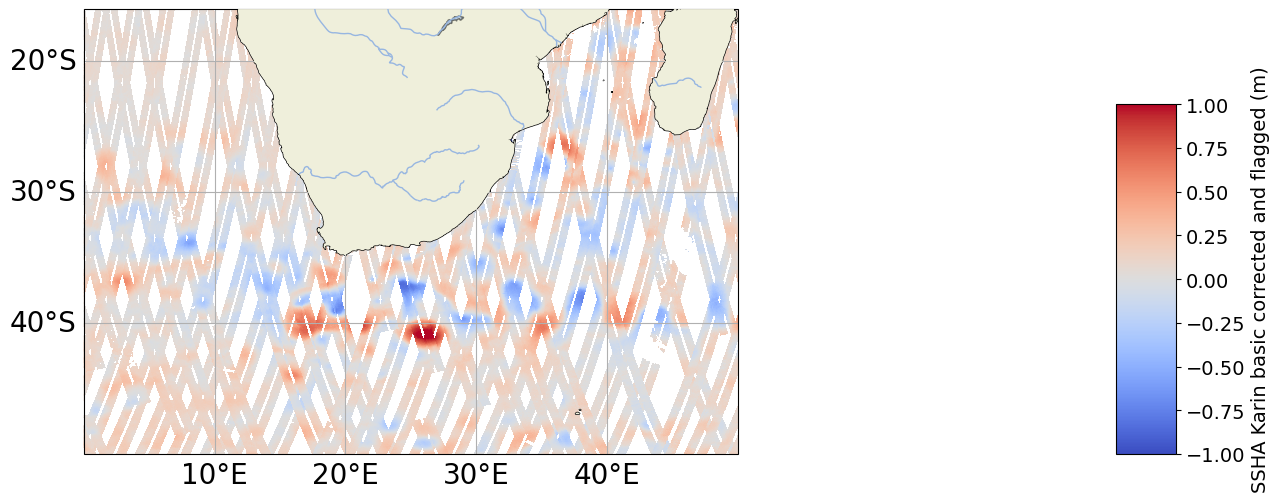

In [17]:
fig = plt.figure(figsize=(15,5))
data_proj = cartopy.crs.PlateCarree(central_longitude=25)
map_proj = cartopy.crs.PlateCarree(central_longitude=25)
ax, gl = init_cartopy(map_proj, box, latstep, lonstep, land) 
palette=plt.cm.seismic
palette.set_bad('w',1.0)
pp=ds_basic.ssha_karin_2_corrected.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude", vmin =-1, vmax=1, cmap='coolwarm', add_colorbar=False)
plt.subplots_adjust(right=0.85,left=0.01,top=0.99,bottom=0.1)
cbar_ax = fig.add_axes([0.9, 0.1, 0.04, 0.7])
h=plt.colorbar(pp, cax=cbar_ax,orientation='vertical')
h.set_label('SSHA Karin basic corrected and flagged (m)',fontsize=14)
h.ax.tick_params(labelsize=14)